#Introduction to Deep Learning
## Cardiac Arrhythmia challenge

Steps to run notebook:
1. Create a copy of this folder in your drive
2. Run the first code block
3. Change 'data_path' to the location of the folder (open folder icon on the left, navigate to this folder, click the 3 dots on the right of the folder to copy path to the folder)







In [1]:
#from google.colab import drive
#drive.mount('/content/gdrive')


In [2]:
# PATH TO THIS FOLDER IN DRIVE
# You must change this path by the corresponding direction of your file
data_path = "/kaggle/input/datasets/poporrinio/data-pulsos"

In [3]:
#data libraries
import numpy as np
import matplotlib.pyplot as plt
import h5py

#model libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

2026-05-22 15:17:46.704320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779463066.892824      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779463066.946008      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779463067.412745      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779463067.412788      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779463067.412791      57 computation_placer.cc:177] computation placer alr

# Extracting the Training Data
The training data is saved in the file 'training_set_500.h5', which is in [h5
format](https://fileinfo.com/extension/h5).  This format allows to save Hierarchical Data.  In this file we have saved the 'data' and the 'labels'

We extract the 'data' and the 'labels' to the variables X_train and y_train respectively and then convert these variable into numpy arrays.

**The dataset has 3 labels :**

*   0: Normal
*   1: Arrhythmia
*   2: Noise




In [4]:
# Traing Data - ECG signals from 500 patients
dataset = h5py.File(data_path + '/training_set_500.h5', 'r')

X_train = dataset.get('data')
X_train = np.array(X_train)
y_train = dataset.get('labels')
y_train = np.array(y_train)
dataset.close()

# Healthy assertion
assert X_train.shape == (116953, 2049, 1)  # The training data has 116953 1D ECG signals each one with 2049 samples
assert y_train.shape == (116953, 1) # 116953 labels (0: Normal, 1: Cardiac Arrhytmia, 2: Noise signal)

In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos de clase
pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=y_train.flatten()   # <- aquí ya son enteros
)

# Convertir a diccionario
class_weights = dict(enumerate(pesos))
print("Pesos calculados:", class_weights)


Pesos calculados: {0: np.float64(0.5979559073153772), 1: np.float64(8.198597967052226), 2: np.float64(0.8294186063004411)}


In [6]:
print(y_train.shape)

(116953, 1)


In [7]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [8]:
nclases = 3
y_train = to_categorical(y_train, nclases)

print(y_train[0])

[1. 0. 0.]


# Extracting the Test Data
The test data is saved in the file '/test_without_labels_200.h5', which is also in [h5
format](https://fileinfo.com/extension/h5).  
We extract the 'data' to the variable X_test. **Please note that the test labels  are hidden for challenge purposes.**

In [9]:
# Testing Data - ECG signals from 200 patients
dataset = h5py.File(data_path + '/test_without_labels_200.h5', 'r')

X_test = dataset.get('data')
X_test = np.array(X_test)
dataset.close()

# Healthy assertion
assert X_test.shape == (46943, 2049, 1) # 46943 1D ECG signal each one with 2049 samples

CALLBACKS

## Sketching some ECG Signal

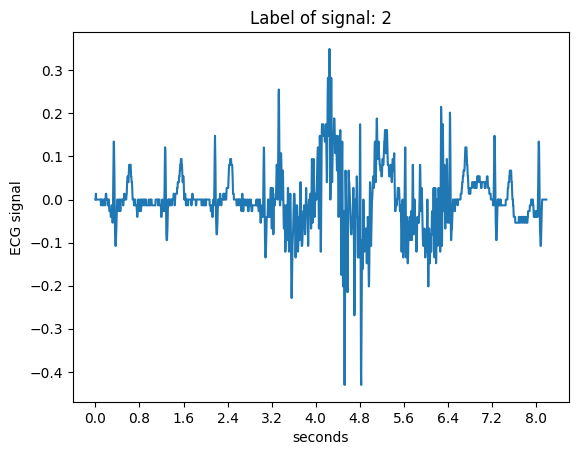

In [10]:
index = 763

x=np.arange(0,2048,200)
xi = x/250 # sample rate of recording: 250Hz
plt.xticks(x,xi)
plt.plot(X_train[index])
plt.title('Label of signal: %i'  % np.argmax(y_train[index]))
plt.xlabel('seconds')
plt.ylabel('ECG signal')

plt.show()

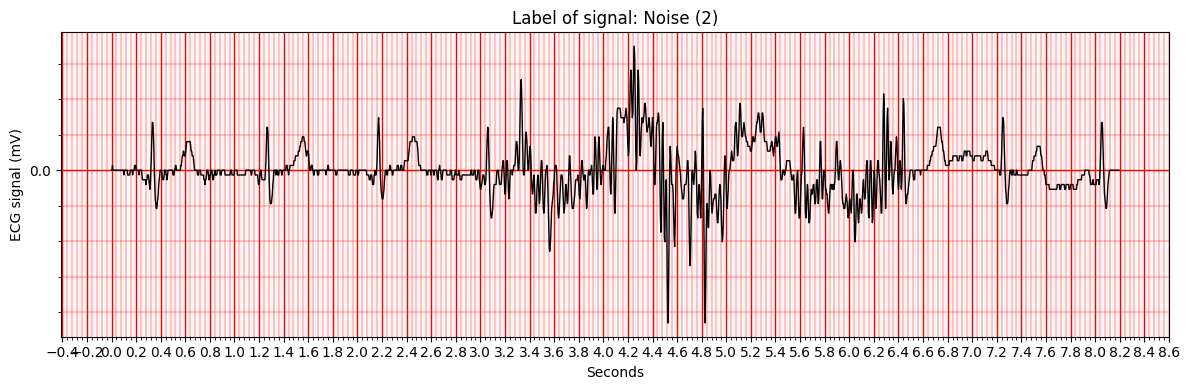

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Parámetros
index = 763
fs = 250  # Frecuencia de muestreo (Hz)
signal = X_train[index]  # Señal de ECG
duration = len(signal) / fs  # Duración en segundos
time = np.arange(len(signal)) / fs  # Eje temporal

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, signal, color='black', linewidth=1)

# Fondo estilo papel ECG
ax.set_facecolor('#fff5f5')  # Fondo rosado muy claro

# Líneas finas (cada 1 mm ~ 0.04s y 0.1mV)
ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='minor', color='red', linestyle='-', linewidth=0.3)

# Líneas gruesas (cada 5 mm ~ 0.2s y 0.5mV)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(which='major', color='red', linestyle='-', linewidth=1)

# Etiquetas y título
ax.set_title(f'Label of signal: Noise ({np.argmax(y_train[index])})')
ax.set_xlabel('Seconds')
ax.set_ylabel('ECG signal (mV)')

plt.tight_layout()
plt.show()

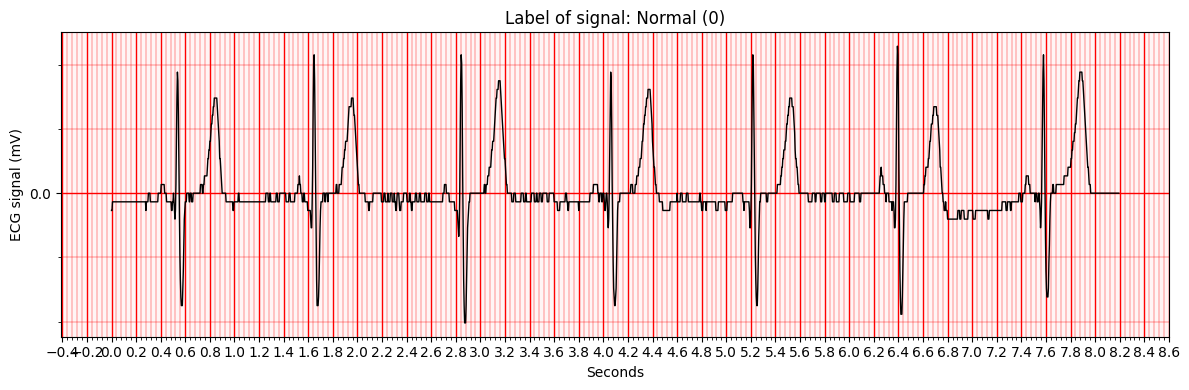

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Parámetros
index = 777
fs = 250  # Frecuencia de muestreo (Hz)
signal = X_train[index]  # Señal de ECG
duration = len(signal) / fs  # Duración en segundos
time = np.arange(len(signal)) / fs  # Eje temporal

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, signal, color='black', linewidth=1)

# Fondo estilo papel ECG
ax.set_facecolor('#fff5f5')  # Fondo rosado muy claro

# Líneas finas (cada 1 mm ~ 0.04s y 0.1mV)
ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='minor', color='red', linestyle='-', linewidth=0.3)

# Líneas gruesas (cada 5 mm ~ 0.2s y 0.5mV)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(which='major', color='red', linestyle='-', linewidth=1)

# Etiquetas y título
ax.set_title(f'Label of signal: Normal ({np.argmax(y_train[index])})')
ax.set_xlabel('Seconds')
ax.set_ylabel('ECG signal (mV)')

plt.tight_layout()
plt.show()


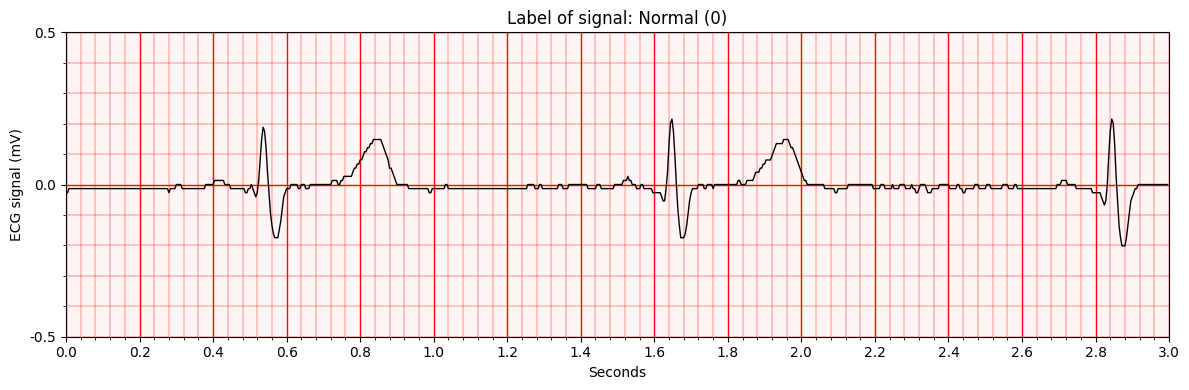

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Parámetros
index = 777
fs = 250  # Frecuencia de muestreo (Hz)
signal = X_train[index][:3*fs]  # Solo los primeros 3 segundos (750 muestras)
time = np.arange(len(signal)) / fs  # Eje temporal

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, signal, color='black', linewidth=1)

# Fondo estilo papel ECG
ax.set_facecolor('#fff5f5')  # Fondo rosado muy claro

# Líneas finas (cada 1 mm ~ 0.04s y 0.1mV)
ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='minor', color='red', linestyle='-', linewidth=0.3)

# Líneas gruesas (cada 5 mm ~ 0.2s y 0.5mV)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(which='major', color='red', linestyle='-', linewidth=1)

# Mostrar números en eje Y
y_min, y_max = -0.5, 0.5
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + 0.5, 0.5))
ax.set_yticklabels([f'{y:.1f}' for y in np.arange(y_min, y_max + 0.5, 0.5)])

# Etiquetas y título
ax.set_title(f'Label of signal: Normal ({np.argmax(y_train[index])})')
ax.set_xlabel('Seconds')
ax.set_ylabel('ECG signal (mV)')

plt.xlim(0, 3)  # Limitar el eje X a 3 segundos

plt.tight_layout()
plt.show()


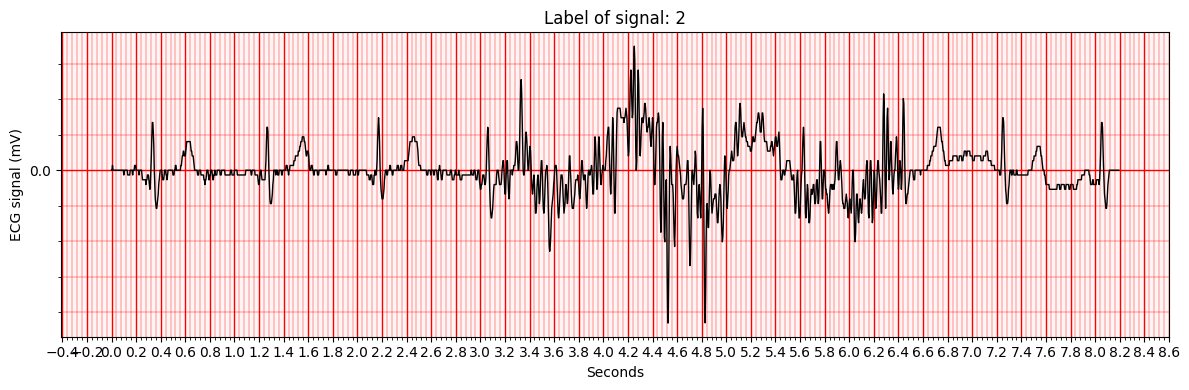

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Parámetros
index = 763
fs = 250  # Frecuencia de muestreo (Hz)
signal = X_train[index]  # Señal de ECG
duration = len(signal) / fs  # Duración en segundos
time = np.arange(len(signal)) / fs  # Eje temporal

# Crear figura
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, signal, color='black', linewidth=1)

# Fondo estilo papel ECG
ax.set_facecolor('#fff5f5')  # Fondo rosado muy claro

# Líneas finas (cada 1 mm ~ 0.04s y 0.1mV)
ax.xaxis.set_minor_locator(MultipleLocator(0.04))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='minor', color='red', linestyle='-', linewidth=0.3)

# Líneas gruesas (cada 5 mm ~ 0.2s y 0.5mV)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(which='major', color='red', linestyle='-', linewidth=1)

# Etiquetas y título
ax.set_title(f'Label of signal: {np.argmax(y_train[index])}')
ax.set_xlabel('Seconds')
ax.set_ylabel('ECG signal (mV)')

plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [16]:
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 180:
        lr *= 0.5e-3
    elif epoch > 160:
        lr *= 1e-3
    elif epoch > 120:
        lr *= 1e-2
    elif epoch > 80:
        lr *= 1e-1
    return lr

Funciones



In [17]:
def residual_block_special(x, filters):
    shortcut = x

    # Camino principal (más simple que el normal)
    x = layers.Conv1D(filters, kernel_size=16, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Conv1D(filters, kernel_size=16, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-2))(x)
    x = layers.AveragePooling1D(pool_size=2, padding='same')(x)

    # Skip connection con MaxPool
    shortcut = layers.MaxPooling1D(pool_size=2, padding='same')(shortcut)

    # Ajuste de canales si cambian
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, padding='same',
                                 kernel_initializer='he_normal')(shortcut)

    # Suma
    x = layers.Add()([x, shortcut])
    return x


In [18]:
def residual_block_n(x, filters):
    shortcut = x

    # Camino principal
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(filters, kernel_size=16, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Conv1D(filters, kernel_size=16, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-2))(x)
    x = layers.AveragePooling1D(pool_size=2, padding='same')(x)

    # Skip connection con MaxPool
    shortcut = layers.MaxPooling1D(pool_size=2, padding='same')(shortcut)

    # Ajusta canales si cambian ← esto es lo que faltaba
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, padding='same',
                                 kernel_initializer='he_normal')(shortcut)

    # Suma
    x = layers.Add()([x, shortcut])
    return x

#Model

In [19]:
def build_model_paper(input_shape=(2049, 1), n_clases=3, Ich=2, N=13):
    inputs = keras.Input(shape=input_shape)

    # ── Capa inicial ─────────────────────────────────────
    x = layers.Conv1D(Ich, kernel_size=16, padding='same',
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)  #Usar otra función de activación (LeakyReLU)

    # ── Primer bloque residual (especial) ────────────────
    x = residual_block_special(x, filters=Ich)

    # ── N bloques residuales — filtros se duplican ───────
    # Según CNN4: [2,2,2,2,4,4,4,4,8,8,8,8,16]
    filter_schedule = []
    for sj in range(N):
        if sj < 4:
            filter_schedule.append(Ich * 1)   # 2
        elif sj < 8:
            filter_schedule.append(Ich * 2)   # 4
        elif sj < 12:
            filter_schedule.append(Ich * 4)   # 8
        else:
            filter_schedule.append(Ich * 8)   # 16

    for filters in filter_schedule:
        x = residual_block_n(x, filters=filters)

    # ── Clasificación final ──────────────────────────────
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(n_clases, activation='softmax',
                           kernel_initializer='glorot_uniform')(x)

    return keras.Model(inputs, outputs)

model = build_model_paper(Ich=8, N=13)
model.summary()

I0000 00:00:1779463101.893875      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2049, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2049, 8)   │        136 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2049, 8)   │         32 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2049, 8)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2049, 8)   │      1,032 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2049, 8)   │         32 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2049, 8)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2049, 8)   │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2049, 8)   │      1,032 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 1025, 8)   │          0 │ conv1d_2[0][0]    │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1025, 8)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1025, 8)   │          0 │ average_pooling1… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 8)   │         32 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1025, 8)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1025, 8)   │      1,032 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1025, 8)   │         32 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1025, 8)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1025, 8)   │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1025, 8)   │      1,032 │ dropout_1[0][0] 

 Total params: 268,267 (1.02 MB)

 Trainable params: 267,067 (1.02 MB)

 Non-trainable params: 1,200 (4.69 KB)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('mejor_modelo.keras', monitor='val_loss',
                    save_best_only=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1)
]



In [21]:
# COMPILE
#model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])


# Compilar
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
# FIT
#history = model.fit(X_train, y_train, epochs= 20, validation_split=0.2, batch_size=32, verbose = 1)
# Entrenar
# FIT
#history = model.fit(X_train, y_train, epochs= 20, validation_split=0.2, batch_size=32, verbose = 1)
# Entrenar
history = model.fit(
    X_train, y_train,
    batch_size=512, #
    epochs=80,
    validation_split=0.2,
    shuffle=True,
    callbacks=callbacks, #Si es posible bajar el learning rate
    class_weight=class_weights
)

#Probar otras funciones de activación

Epoch 1/80


I0000 00:00:1779463124.210407     128 service.cc:152] XLA service 0x7bb560004e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779463124.210440     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779463127.760487     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779463158.705361     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5494 - loss: 7.1395
Epoch 1: val_loss improved from inf to 1.63710, saving model to mejor_modelo.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 129s 416ms/step - accuracy: 0.5499 - loss: 7.1238 - val_accuracy: 0.7191 - val_loss: 1.6371 - learning_rate: 0.0010
Epoch 2/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7823 - loss: 1.1604
Epoch 2: val_loss improved from 1.63710 to 0.84310, saving model to mejor_modelo.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 37s 205ms/step - accuracy: 0.7825 - loss: 1.1594 - val_accuracy: 0.8147 - val_loss: 0.8431 - learning_rate: 0.0010
Epoch 3/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8485 - loss: 0.6469
Epoch 3: val_loss improved from 0.84310 to 0.60231, saving model to mejor_modelo.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 37s 204ms/step - accuracy: 0.8486 - loss: 0.6466 - val_accuracy: 0.8592 - val_loss: 0.6023 - learning_rate: 0.0010
Epoch 4/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - a

Graficas

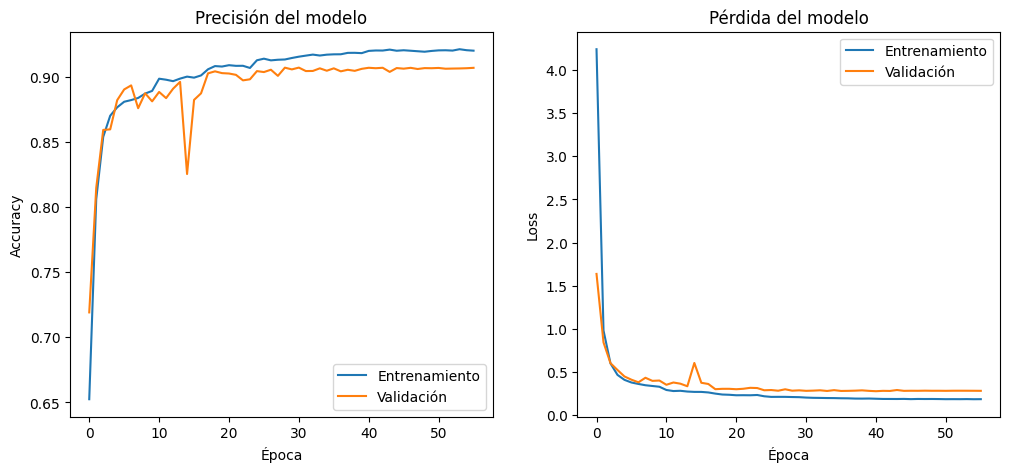

In [23]:
# Graficar Accuracy y Loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Calculate the predictions on the X_test, save and submit the results

When you are satisfied with your results:

*   Calculate y_pred, which is the prediction for the X_test
*   Save it on a .npy file
*   Submit your results on the Classroom

I will sent you the accuracy on this file.

In [24]:
y_pred = model.predict(X_test)
y_pred = (y_pred == y_pred.max(axis=1)[:,None]).astype(int)
assert y_pred.shape == (46943,3)


1467/1467 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step


In [25]:
print(y_pred)

[[0 0 1]
 [1 0 0]
 [1 0 0]
 ...
 [0 0 1]
 [0 0 1]
 [1 0 0]]


In [26]:
# Guardar predicciones en Kaggle
np.save('/kaggle/working/GROUP_CODE1_CODE2_NAME1_NAME2_prediction.npy', y_pred)

In [27]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_train)
y_pred_clases = np.argmax(y_pred, axis=1)
y_true_clases = np.argmax(y_train, axis=1)

print(classification_report(y_true_clases, y_pred_clases,
      target_names=['Normal', 'Arritmia', 'Ruido']))

3655/3655 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
              precision    recall  f1-score   support

      Normal       0.95      0.93      0.94     65196
    Arritmia       0.74      0.95      0.83      4755
       Ruido       0.92      0.91      0.91     47002

    accuracy                           0.92    116953
   macro avg       0.87      0.93      0.90    116953
weighted avg       0.93      0.92      0.92    116953



3655/3655 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step


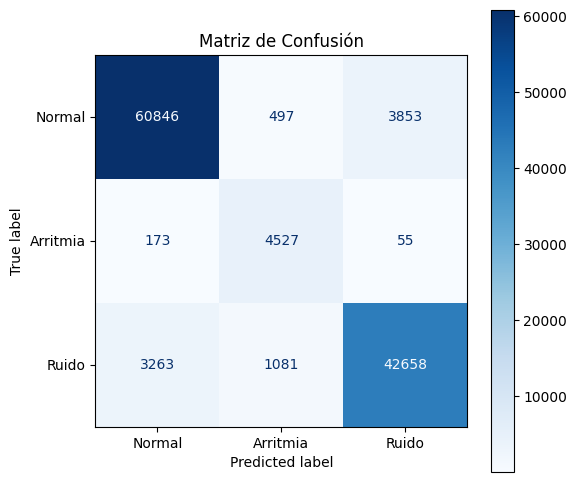

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predicciones y etiquetas reales
y_pred = model.predict(X_train)
y_pred_clases = np.argmax(y_pred, axis=1)
y_true_clases = np.argmax(y_train, axis=1)

# Calcular matriz de confusión
cm = confusion_matrix(y_true_clases, y_pred_clases)

# Mostrar con nombres de clases
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Normal','Arritmia','Ruido'])

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Matriz de Confusión")
plt.show()


In [29]:
# Guardar el modelo
model.save('/kaggle/working/modelo_resnet20_ecg.keras')

# Verificar que se guardó
import os
print(os.listdir('/kaggle/working/'))

['GROUP_CODE1_CODE2_NAME1_NAME2_prediction.npy', 'modelo_resnet20_ecg.keras', 'mejor_modelo.keras', '.virtual_documents']


In [30]:
# Guardar solo los pesos (nombre correcto)
model.save_weights('/kaggle/working/pesos_cnn4.weights.h5')

model.save('/kaggle/working/modelo_cnn4.keras')


Cargar el modelo

In [31]:
# Reconstruir la arquitectura
model = build_model_paper(Ich=8, N=13)

# Compilar antes de cargar pesos
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Cargar los pesos
model.load_weights('/kaggle/working/pesos_cnn4.weights.h5')




/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 250 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
